# NLP Example: Parameter Fitting by Sum-of-Squares Minimization

CHBE444: Design I, Prof. Ganesh Sriram (gsriram@umd.edu), University of Maryland.

A chemical engineer is using a mathematical model to predict the concentrations C₁ to C₄ of four compounds in a reactor as a function of two process variables $x_1$ and $x_2$:

$$
C_{1}=1-\frac{2x_{1}}{2-x_{1}}C
$$

$$
C_{2}=\frac{1}{1+2x_{1}x_{2}}
$$

$$
C_{3}=\left(1-\frac{2x_{1}}{2-x_{1}}C+C_{2}\right)\frac{x_{1}x_{2}}{1+x_{1}x_{2}}
$$

$$
C_{4}=\left(1-\frac{2x_{1}}{2-x_{1}}C+C_{2}\right)\frac{x_{1}x_{2}}{1+x_{1}x_{2}}+C_{2}
$$

$$C=\frac{1-x_{1}x_{2}}{1+2x_{1}x_{2}}$$

The following experimental measurements were obtained for the concentrations: $C_1$, 0.84; $C_2$, 0.80; $C_3$, 0.16; $C_4$, 0.88. The engineer wants to find the values of the parameters $x_1$ and $x_2$ that best account for the experimental data.

In [2]:
import numpy as np
import scipy.optimize as opt


def ssr(x, C_exp):
    x1 = x[0]
    x2 = x[1]
    sig = 1

    C_pred = np.zeros(4)
    C = (1 - x1 * x2) / (1 + 2 * x1 * x2)
    C1 = 1 - 2 * x1 / (2 - x1) * C
    C2 = 1 / (1 + 2 * x1 * x2)
    C3 = (1 - 2 * x1 / (2 - x1) * C + C2) * (x1 * x2) / (1 + x1 * x2)
    C4 = (1 - 2 * x1 / (2 - x1) * C + C2) * (x1 * x2) / (1 + x1 * x2) + C2

    C_pred = [C1, C2, C3, C4]

    ssr = 0
    for i in range(0, 4):
        ssr += (C_pred[i] - C_expt[i])**2 / sig**2

    return ssr


C_expt = [0.84, 0.80, 0.16, 0.88]

res = opt.minimize(
    ssr, [0, 1], args=(C_expt),
    method='nelder-mead',
    options={'xatol': 1e-8, 'disp': True})

print('Optimal x:', res.x)
print('Optimal z:', res.fun)

Optimization terminated successfully.
         Current function value: 0.010723
         Iterations: 82
         Function evaluations: 158
Optimal x: [0.21793747 0.5580177 ]
Optimal z: 0.01072297886140723


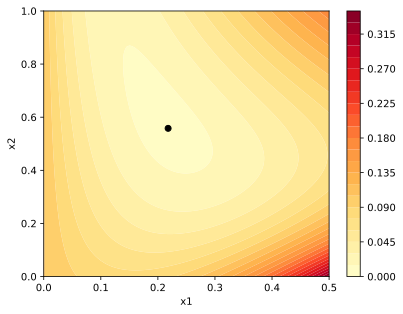

In [6]:
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = 'svg'
%matplotlib inline

x1 = np.linspace(0, 0.5, 101)
x2 = np.linspace(0, 1, 201)
X1, X2 = np.meshgrid(x1, x2)

S = ssr([X1, X2], C_expt)

p = plt.contourf(X1, X2, S, levels=25, cmap='YlOrRd')
plt.xlabel('x1')
plt.ylabel('x2')
plt.plot(res.x[0], res.x[1], 'ko')
plt.colorbar()
plt.show()